In [ ]:
!pip install pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 8.5 MB/s eta 0:00:00


In [ ]:
from pgmpy.models import BayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


In [ ]:
from pgmpy.models import DiscreteBayesianNetwork
# Define Structure (Graph)
model = DiscreteBayesianNetwork([
    ('StudyHours', 'InternalMarks'),
    ('Attendance', 'InternalMarks'),
    ('InternalMarks', 'Pass')
])

In [ ]:
# Define CPDs (Probabilities)

# Study Hours (0 = Low, 1 = High)
cpd_study = TabularCPD(
    variable='StudyHours',
    variable_card=2,
    values=[[0.6],   # Low
            [0.4]]   # High
)

# Attendance (0 = Irregular, 1 = Regular)
cpd_attendance = TabularCPD(
    variable='Attendance',
    variable_card=2,
    values=[[0.5],   # Irregular
            [0.5]]   # Regular
)

# Internal Marks depends on StudyHours & Attendance
cpd_internal = TabularCPD(
    variable='InternalMarks',
    variable_card=2,
    values=[
        [0.9, 0.6, 0.5, 0.2],  # Low
        [0.1, 0.4, 0.5, 0.8]   # High
    ],
    evidence=['StudyHours', 'Attendance'],
    evidence_card=[2, 2]
)

In [ ]:
# Pass depends on Internal Marks
cpd_pass = TabularCPD(
    variable='Pass',
    variable_card=2,
    values=[
        [0.8, 0.2],  # Fail
        [0.2, 0.8]   # Pass
    ],
    evidence=['InternalMarks'],
    evidence_card=[2]
)

In [ ]:
# Add CPDs to Model
model.add_cpds(cpd_study, cpd_attendance, cpd_internal, cpd_pass)

In [ ]:
# Validate Model
assert model.check_model()

In [ ]:
# Inference
inference = VariableElimination(model)

In [ ]:
# Query: Probability of Passing
result = inference.query(
    variables=['Pass'],
    evidence={
        'StudyHours': 1,   # High
        'Attendance': 1    # Regular
    }
)

In [ ]:
print(result)

+---------+-------------+
| Pass    |   phi(Pass) |
+=========+=============+
| Pass(0) |      0.3200 |
+---------+-------------+
| Pass(1) |      0.6800 |
+---------+-------------+


In [ ]:
# Graph Visualization
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
# Create directed graph
G = nx.DiGraph()

In [ ]:
# Add edges (same as your model structure)
G.add_edges_from([
    ('StudyHours', 'InternalMarks'),
    ('Attendance', 'InternalMarks'),
    ('InternalMarks', 'Pass')
])

In [ ]:
# Define layout
pos = nx.spring_layout(G)

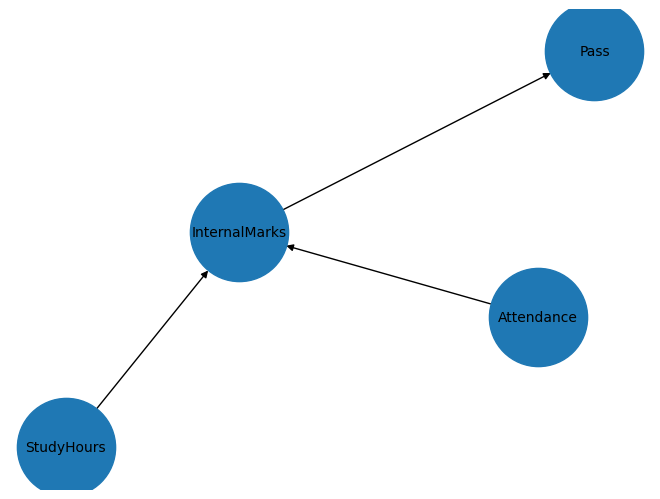

In [ ]:
# Draw graph
nx.draw(
    G, pos,
    with_labels=True,
    node_size=5000,
    font_size=10,
    arrows=True
)